<a href="https://colab.research.google.com/github/makxxic/ICP-YDR32P-2026-REPO/blob/main/project1_Binary_Classification_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Breast Cancer Dataset Classifier**

The following link https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data contains data that correlates the features computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. It is used to classify the mass as either benign (B) or malignant (M).

Aim is to implement a 3-layer neural network to classify a breast mass sample based on this dataset.





# 1. Imports
We start by importing the libraries we need.

- **pandas**: For handling tabular data.
- **numpy**: For numerical operations.
- **matplotlib**: For plotting graphs.
- **scikit-learn**: For preprocessing (scaling features, splitting data).
- **torch**: PyTorch library for building and training neural networks.


In [1]:
import kagglehub as kh
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier

import torch
from torch import nn
from torch.optim import SGD
import torch.optim as optim


# 2. Dataset Loading
Load the Breast Cancer Wisconsin dataset from Kaggle.

  
We need real-world data to train our model. This dataset contains features computed from breast cancer cell images in each row, and the target is whether the tumor is **malignant (cancerous)** or **benign (non-cancerous)**.


In [2]:
# Download the breast dataset
path = kh.dataset_download("uciml/breast-cancer-wisconsin-data")

df = pd.read_csv(path + "/data.csv")

df.head()

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


#3. Data Exploration
Explore the dataset to understand:
 - What features are available - Whether there are missing values
 - The distribution of the target variable
 # Feature Engineering
Prepare the dataset for training:
- Convert target labels (M = malignant, B = benign) into binary values (1 and 0).
- Drop unnecessary columns (like ID).
- Scale features so they are on the same range (important for neural networks).


Neural networks work best when inputs are scaled and labels are numeric.



In [3]:
# Implement feature engineering on the data.
df['diagnosis'].value_counts()# Count malignant vs benign cases
# Convert labels to binary, using replace for robustness
df['diagnosis'] = df['diagnosis'].replace({'M':1, 'B':0})

# Drop unnecessary columns, ignore if not found
df = df.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore')

# Features
X = df.drop('diagnosis', axis=1).values
# Target
y = df['diagnosis'].values

# Handle potential NaNs in y before scaling or splitting
nan_mask = np.isnan(y)
if np.any(nan_mask):
    # Drop rows with NaN in diagnosis from both X and y
    X = X[~nan_mask]
    y = y[~nan_mask]
    print(f"Removed {np.sum(nan_mask)} rows with NaN values in 'diagnosis'.")



/tmp/ipykernel_58110/313722518.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['diagnosis'] = df['diagnosis'].replace({'M':1, 'B':0})


In [4]:
# Print the shape of the features and target to verify
print(f"Features shape: {X.shape}") # Should be (569, 30)
print(f"Target shape: {y.shape}")   # Should be (569,)

Features shape: (569, 30)
Target shape: (569,)


# 4. Train–Validation Split
Split the dataset into:
- **Training set (90%)**: Used to train the model.
- **Validation set (10%)**: Used to evaluate performance.

We must test our model on unseen data to check if it generalizes well.


In [5]:
# Split processed dataframe into test and validation sets.
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.1,
    shuffle=True,
    random_state=42,
    stratify=y
)

In [6]:
print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Training samples: 512
Validation samples: 57


In [7]:
# Initialize scaler and scale features
scaler = StandardScaler()

# Fit the scaler on the TRAINING data only, then transform the training data
# We do not fit on validation data to prevent "data leakage" (cheating)
X_train_scaled = scaler.fit_transform(X_train)

# Transform the validation data using the stats learned from the training data
X_val_scaled = scaler.transform(X_val)

## 5. Baseline Models (Logistic Regression & Decision Tree)
  
Before jumping to neural networks, we test simpler models:

Logistic Regression: interpretable linear model, coefficients show feature importance.

Decision Tree: non-linear model, feature importance shows which features drive splits.

In [8]:

# Logistic Regression
log_reg = LogisticRegression(max_iter=5000) # Increased max_iter to prevent ConvergenceWarning
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_val)
print("Logistic Regression Accuracy:", accuracy_score(y_val, y_pred_lr))
print(classification_report(y_val, y_pred_lr))

# Decision Tree
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_val)
print("Decision Tree Accuracy:", accuracy_score(y_val, y_pred_tree))
print(classification_report(y_val, y_pred_tree))

Logistic Regression Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        36
           1       1.00      0.90      0.95        21

    accuracy                           0.96        57
   macro avg       0.97      0.95      0.96        57
weighted avg       0.97      0.96      0.96        57

Decision Tree Accuracy: 0.9122807017543859
              precision    recall  f1-score   support

           0       0.90      0.97      0.93        36
           1       0.94      0.81      0.87        21

    accuracy                           0.91        57
   macro avg       0.92      0.89      0.90        57
weighted avg       0.91      0.91      0.91        57



## 6. Feature Insights
Interpretability is crucial in medical applications.

Logistic Regression coefficients show how each feature influences malignancy probability.

Decision Tree feature importance shows which features drive splits.

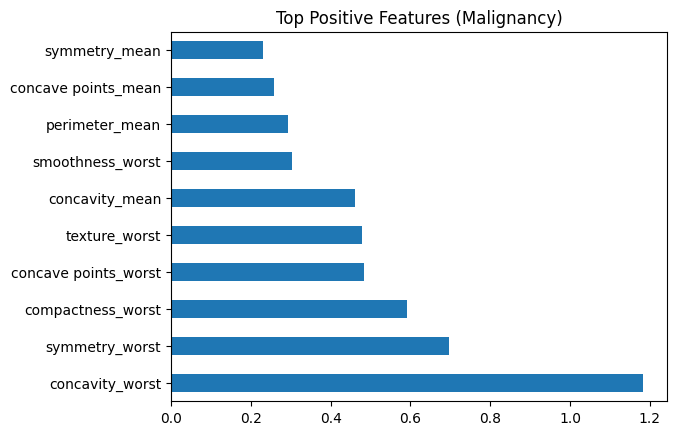

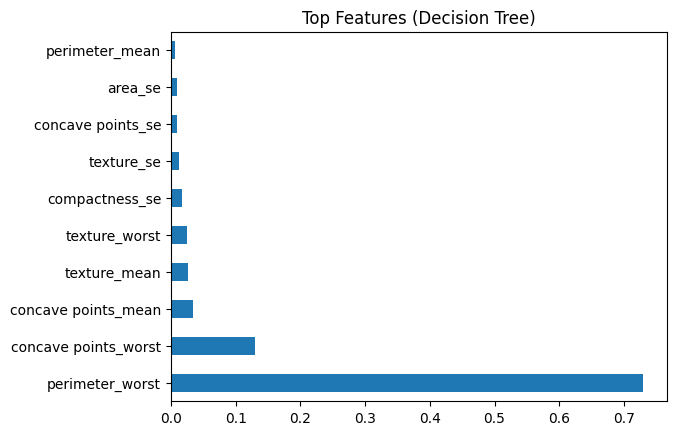

In [9]:
# Logistic Regression Coefficients
coef = pd.Series(log_reg.coef_[0], index=df.drop('diagnosis', axis=1).columns)
coef.sort_values(ascending=False).head(10).plot(kind='barh', title="Top Positive Features (Malignancy)")
plt.show()

# Decision Tree Feature Importance
importance = pd.Series(tree.feature_importances_, index=df.drop('diagnosis', axis=1).columns)
importance.sort_values(ascending=False).head(10).plot(kind='barh', title="Top Features (Decision Tree)")
plt.show()


## 7. Neural Network Architecture
We now move to a more complex model,

Build a neural network with:

Input layer: 30 features.

2 Hidden layers: ReLU activation (introduces non-linearity).

Output layer: Sigmoid activation for binary classification (probability between 0 and 1).

Why ReLU? Efficient gradient propagation, avoids vanishing gradients, helps hidden layers learn non-linear relationships.

Why Sigmoid? Converts output into probability for binary classification.

Why SGD? Slower but stable with weight decay (L2 regularization). Adam could converge faster.

Neural networks learn complex patterns in data. .


In [10]:
# Implement neural network architecture here

# Define neural network using Sequential container
model = nn.Sequential(
    nn.Linear(30, 16),   # First hidden layer (30 -> 16)
    nn.ReLU(),           # ReLU activation
    nn.Linear(16, 8),    # Second hidden layer (16 -> 8)
    nn.ReLU(),           # ReLU activation
    nn.Linear(8, 1),     # Output layer (8 -> 1)
    nn.Sigmoid()         # Sigmoid activation for probability output
)


# 8. Tensor Conversion
Convert numpy arrays into PyTorch tensors.


PyTorch models only work with tensors, which are its special data structure for numerical computation.


In [11]:
# Get the PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

# 9. Hyperparameters and Loss
Define:
- **Learning rate**: Step size for optimization (0.01 is a safe choice for SGD).
- **Optimizer**: Stochastic Gradient Descent (SGD) with L2 regularization (weight decay).
- **Loss function**: Binary Cross Entropy (BCE) for binary classification.

The optimizer updates weights, the loss function measures error, and hyperparameters control training speed and stability.


In [12]:
# Define hyperparameters

learning_rate = 0.001
# Loss Function: Binary Cross Entropy Loss
# Used specifically for binary classification (0 or 1)
criterion = nn.BCELoss() # Binary Cross Entropy loss
# Optimizer: Stochastic Gradient Descent (SGD)
# lr: learning rate
# weight_decay: L2 Regularization (0.001) helps prevent overfitting
optimizer = optim.SGD(model.parameters(), lr=learning_rate,momentum=0.9, weight_decay=0.001)

print(f"Optimizer: SGD, Loss: BCELoss, LR: {learning_rate}")

Optimizer: SGD, Loss: BCELoss, LR: 0.001


# 10. Training Loop with Early Stopping
Train the model:
- Forward pass: Compute predictions
- Loss calculation: Compare predictions with true labels
- Backward pass: Update weights using optimizer
- Early stopping: Stop training if validation loss does not improve for several epochs

Early stopping prevents overfitting and saves time by halting training when the model stops improving.


In [13]:
epochs = 1000            # Maximum number of epochs
patience = 20             # Patience for early stopping
best_val_loss = float('inf')
patience_counter = 0
train_losses = []
val_losses = []
train_accuracy = []
val_accuracy = []

for epoch in range(epochs):
    # --- Training phase ---
    model.train()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Calculate training accuracy
    train_preds = (outputs > 0.5).float()
    train_acc = (train_preds == y_train_tensor).sum().item() / float(y_train_tensor.shape[0])
    train_accuracy.append(train_acc)

    # --- Validation phase ---
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val_tensor)
        val_loss = criterion(y_val_pred, y_val_tensor)
        y_val_pred_class = (y_val_pred > 0.5).float()
        val_acc = (y_val_pred_class == y_val_tensor).sum().item() / float(y_val_tensor.shape[0])
        val_accuracy.append(val_acc)
        val_losses.append(val_loss.item())

    # Print progress every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}, '
              f'Val Loss: {val_loss.item():.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

    # --- Early stopping check ---
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_accuracy = val_acc
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}!")
        break

# Load best model
model.load_state_dict(torch.load('best_model.pth'))


Epoch [50/1000], Train Loss: 0.7004, Val Loss: 0.7036, Train Acc: 0.3730, Val Acc: 0.3684
Epoch [100/1000], Train Loss: 0.6588, Val Loss: 0.6631, Train Acc: 0.7910, Val Acc: 0.7719
Epoch [150/1000], Train Loss: 0.6183, Val Loss: 0.6239, Train Acc: 0.9258, Val Acc: 0.8947
Epoch [200/1000], Train Loss: 0.5713, Val Loss: 0.5774, Train Acc: 0.9160, Val Acc: 0.8772
Epoch [250/1000], Train Loss: 0.5143, Val Loss: 0.5210, Train Acc: 0.9316, Val Acc: 0.8772
Epoch [300/1000], Train Loss: 0.4464, Val Loss: 0.4530, Train Acc: 0.9355, Val Acc: 0.9298
Epoch [350/1000], Train Loss: 0.3738, Val Loss: 0.3785, Train Acc: 0.9453, Val Acc: 0.9474
Epoch [400/1000], Train Loss: 0.3069, Val Loss: 0.3081, Train Acc: 0.9473, Val Acc: 0.9474
Epoch [450/1000], Train Loss: 0.2534, Val Loss: 0.2503, Train Acc: 0.9492, Val Acc: 0.9649
Epoch [500/1000], Train Loss: 0.2135, Val Loss: 0.2061, Train Acc: 0.9512, Val Acc: 0.9649
Epoch [550/1000], Train Loss: 0.1845, Val Loss: 0.1728, Train Acc: 0.9512, Val Acc: 0.9825


<All keys matched successfully>

# 11. Loss Plot
Plot training loss vs epochs.

Visualizing loss helps us understand whether the model is learning properly and when it starts overfitting.


In [14]:
def plot_losses(plt, title, train_losses, val_losses, label):
    plt.plot(train_losses, label=f"Train {label}")
    plt.plot(val_losses, label=f"Validation {label}")
    plt.legend()
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(label)

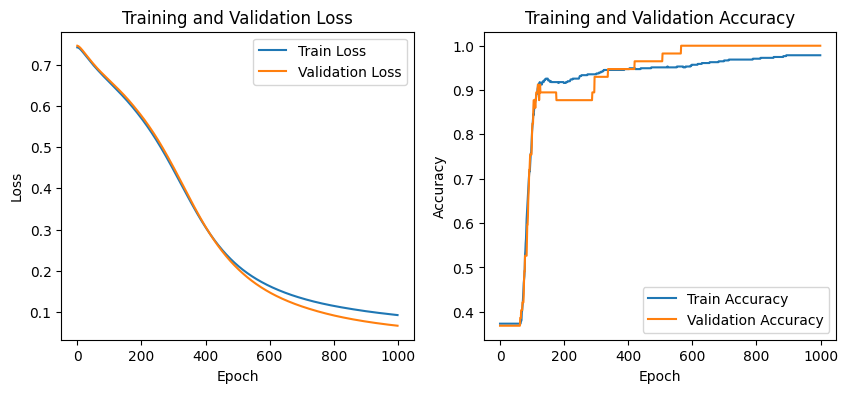

In [15]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plot_losses(plt, "Training and Validation Loss", train_losses, val_losses, label="Loss")
plt.subplot(1, 2, 2)
plot_losses(plt, "Training and Validation Accuracy", train_accuracy, val_accuracy, label="Accuracy")
plt.show()

# 12. Final Evaluation
Evaluate the model on the validation set:
- Compute predictions
- Convert probabilities to binary labels (0 or 1)
- Calculate accuracy
- Print final results


In [17]:
print("Logistic Regression Accuracy:", accuracy_score(y_val, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_val, y_pred_tree))
print("Neural Network Accuracy:", best_accuracy)

Logistic Regression Accuracy: 0.9649122807017544
Decision Tree Accuracy: 0.9122807017543859
Neural Network Accuracy: 1.0


In [18]:
# At the end of the training print: Accuracy of the model on the validation data, Number of epochs to get to that accuracy, Criterion used
model.eval()
with torch.no_grad():
    val_probs = model(X_val_tensor)
    val_preds = (val_probs >= 0.5).float()
    correct = (val_preds == y_val_tensor).sum().item()
    total = y_val_tensor.size(0)
    accuracy = correct / total * 100

print("Validation Accuracy: {:.2f}%".format(accuracy))
print("Epochs to reach best accuracy:", best_epoch)
print("Criterion used:", criterion.__class__.__name__)


Validation Accuracy: 100.00%
Epochs to reach best accuracy: 1000
Criterion used: BCELoss


## 11. Confusion Matrices
  
A confusion matrix shows how many samples were correctly classified vs misclassified.

True Positives (TP): malignant correctly predicted.

True Negatives (TN): benign correctly predicted.

False Positives (FP): benign misclassified as malignant.

False Negatives (FN): malignant misclassified as benign.



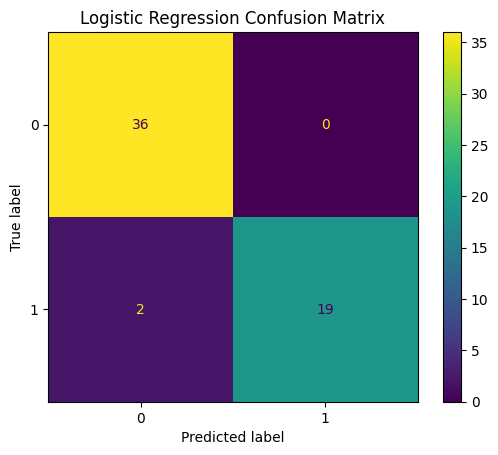

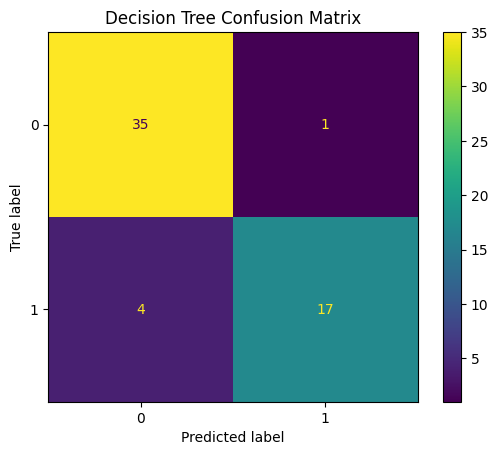

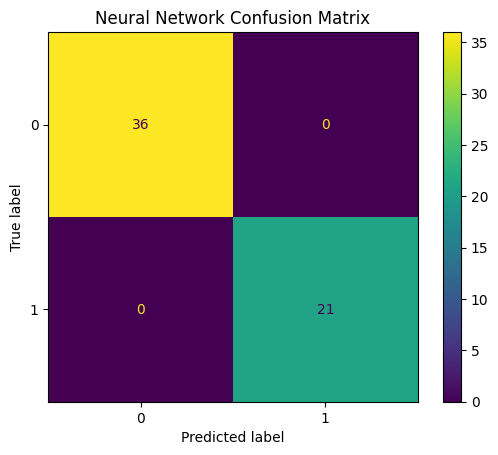

In [19]:
# Logistic Regression
cm_lr = confusion_matrix(y_val, y_pred_lr)
ConfusionMatrixDisplay(cm_lr).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Decision Tree
cm_tree = confusion_matrix(y_val, y_pred_tree)
ConfusionMatrixDisplay(cm_tree).plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

# Neural Network
model.eval()
with torch.no_grad():
    nn_probs = model(X_val_tensor).numpy()
    nn_preds = (nn_probs > 0.5).astype(int)
cm_nn = confusion_matrix(y_val, nn_preds)
ConfusionMatrixDisplay(cm_nn).plot()
plt.title("Neural Network Confusion Matrix")
plt.show()
